In [1]:
# importamos las librerias necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# funcion que aplica el pipeline mejorado:
# 1. desenfoque previo para reducir textura del fondo
# 2. canny con los umbrales
# 3. cierre morfologico + dilatacion para cerrar huecos y engrosar bordes
# 4. seleccion del contorno mas grande que este cerca del centro de la imagen
# 5. mascara y segmentacion con fondo blanco
def segmentar(ruta, umbral_bajo, umbral_alto, k=5, blur=7, peso_centro=0.5):
    imagen = cv2.imread(ruta)
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # mejora 1: desenfoque bilateral, suaviza fondo sin matar bordes del sujeto
    suavizada = cv2.bilateralFilter(gris, blur, 75, 75)
    canny = cv2.Canny(suavizada, umbral_bajo, umbral_alto)
    kernel = np.ones((k, k), np.uint8)
    # mejora 2: cierre morfologico para tapar huecos del contorno + dilatacion
    cerrados = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel)
    bordes = cv2.dilate(cerrados, kernel)
    contornos, _ = cv2.findContours(bordes, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # mejora 3: puntuamos contornos por area + cercania al centro
    h, w = bordes.shape
    centro_img = np.array([w / 2, h / 2])
    diag = np.sqrt(w * w + h * h)
    def puntaje(c):
        area = cv2.contourArea(c)
        if area < 100:
            return -1
        M = cv2.moments(c)
        if M['m00'] == 0:
            return -1
        cx, cy = M['m10'] / M['m00'], M['m01'] / M['m00']
        dist = np.linalg.norm(np.array([cx, cy]) - centro_img) / diag
        return area / (w * h) - peso_centro * dist
    mejor = max(contornos, key=puntaje)
    objetos = bordes.copy()
    cv2.drawContours(objetos, [mejor], -1, 255, thickness=-1)
    objetos = objetos / 255
    segmentada = np.zeros(imagen.shape)
    segmentada[:, :, 0] = objetos * imagen[:, :, 0] + 255 * (objetos == 0)
    segmentada[:, :, 1] = objetos * imagen[:, :, 1] + 255 * (objetos == 0)
    segmentada[:, :, 2] = objetos * imagen[:, :, 2] + 255 * (objetos == 0)
    segmentada = np.uint8(segmentada)
    return imagen, canny, bordes, segmentada

In [3]:
# funcion auxiliar para mostrar lado a lado original, canny y segmentada
# si recibe guardar_en, guarda el composite de las 3 en esa ruta
def mostrar(imagen, canny, segmentada, titulo, guardar_en=None):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    ax[0].set_title('original')
    ax[0].axis('off')
    ax[1].imshow(canny, cmap='gray')
    ax[1].set_title('canny')
    ax[1].axis('off')
    ax[2].imshow(cv2.cvtColor(segmentada, cv2.COLOR_BGR2RGB))
    ax[2].set_title('segmentada')
    ax[2].axis('off')
    plt.suptitle(titulo)
    if guardar_en is not None:
        import os
        os.makedirs(os.path.dirname(guardar_en), exist_ok=True)
        plt.savefig(guardar_en, bbox_inches='tight', dpi=120)
    plt.show()

In [4]:
# funcion para comparar como cambia el canny al mover los umbrales
# si recibe guardar_en, guarda el composite
def comparar_umbrales(ruta, pares, blur=7, guardar_en=None):
    gris = cv2.cvtColor(cv2.imread(ruta), cv2.COLOR_BGR2GRAY)
    suavizada = cv2.bilateralFilter(gris, blur, 75, 75)
    fig, ax = plt.subplots(1, len(pares), figsize=(5 * len(pares), 5))
    for i, (b, a) in enumerate(pares):
        c = cv2.Canny(suavizada, b, a)
        ax[i].imshow(c, cmap='gray')
        ax[i].set_title(f'bajo={b}, alto={a}')
        ax[i].axis('off')
    if guardar_en is not None:
        import os
        os.makedirs(os.path.dirname(guardar_en), exist_ok=True)
        plt.savefig(guardar_en, bbox_inches='tight', dpi=120)
    plt.show()

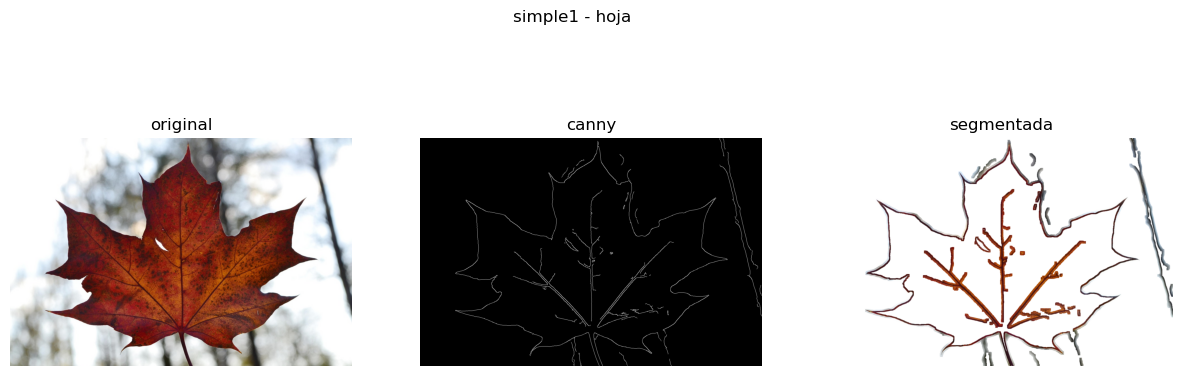

In [5]:
# imagen simple 1: hoja
# kernel moderado para no redondear los picos
img1, canny1, bordes1, seg1 = segmentar('simple1.jpg', 20, 100, k=9, blur=9)
mostrar(img1, canny1, seg1, 'simple1 - hoja', guardar_en='output/simple1/comparativa.png')

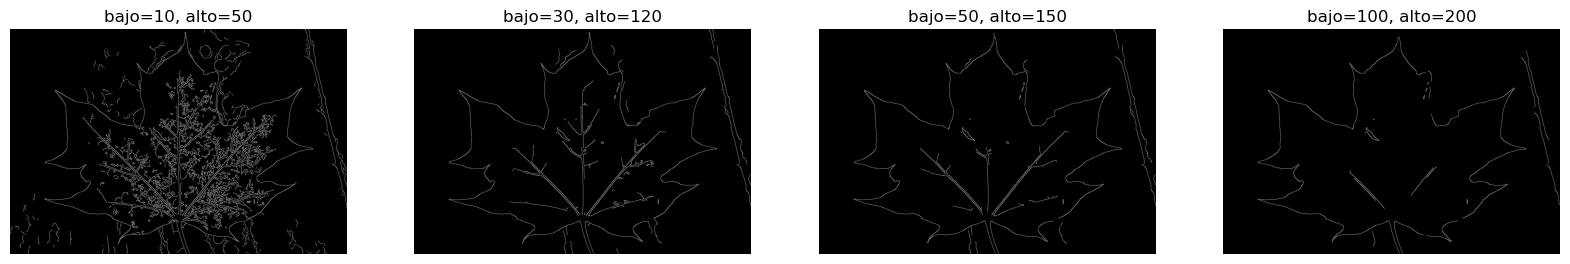

In [6]:
# comparacion de umbrales sobre la hoja
comparar_umbrales('simple1.jpg', [(10, 50), (30, 120), (50, 150), (100, 200)], guardar_en='output/simple1/umbrales.png')

In [7]:
# bloque para guardar los outputs de simple1
import os
os.makedirs('output/simple1', exist_ok=True)
cv2.imwrite('output/simple1/canny.png', canny1)
cv2.imwrite('output/simple1/bordes_dilatados.png', bordes1)
cv2.imwrite('output/simple1/segmentada.png', seg1)

True

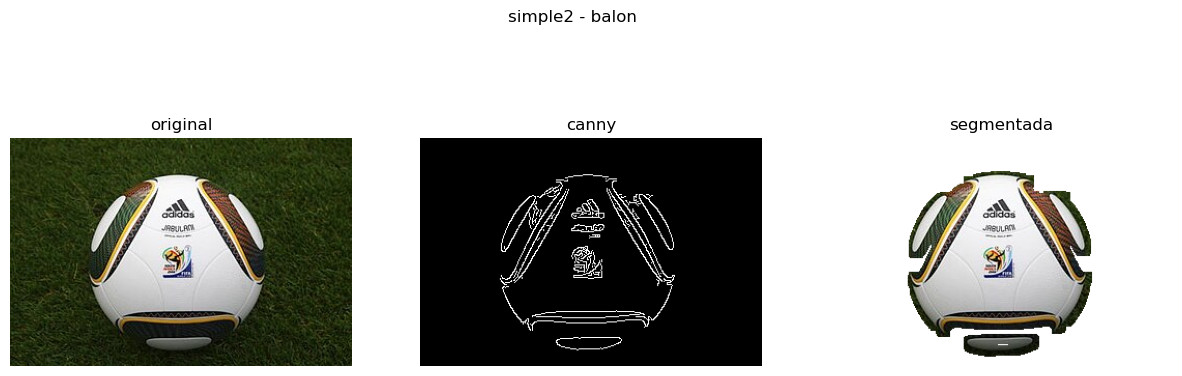

In [8]:
# imagen simple 2: balon sobre pasto
# umbral alto agresivo y kernel grande para borrar el cesped
img2, canny2, bordes2, seg2 = segmentar('simple2.jpg', 20, 200, k=10, blur=9)
mostrar(img2, canny2, seg2, 'simple2 - balon', guardar_en='output/simple2/comparativa.png')

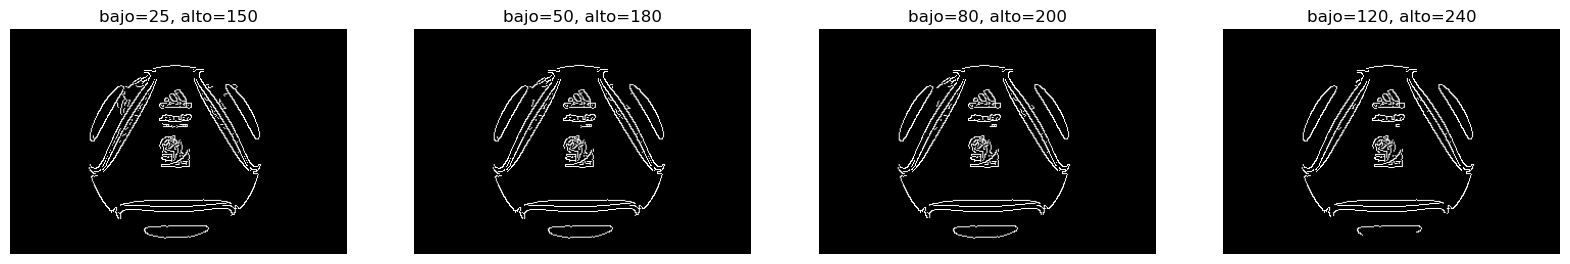

In [9]:
# comparacion de umbrales sobre el balon
comparar_umbrales('simple2.jpg', [(25, 150), (50, 180), (80, 200), (120, 240)], blur=9, guardar_en='output/simple2/umbrales.png')

In [10]:
# bloque para guardar los outputs de simple2
import os
os.makedirs('output/simple2', exist_ok=True)
cv2.imwrite('output/simple2/canny.png', canny2)
cv2.imwrite('output/simple2/bordes_dilatados.png', bordes2)
cv2.imwrite('output/simple2/segmentada.png', seg2)

True

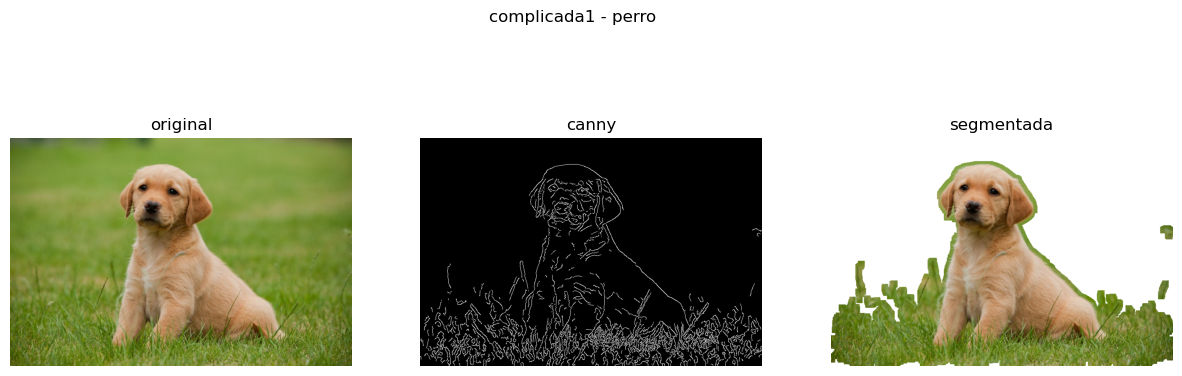

In [11]:
# imagen complicada 1: perro sobre pasto
# canny necesita bajo < alto, ratio 1:2 o 1:3 para que funcione la histeresis
img3, canny3, bordes3, seg3 = segmentar('complicada1.jpg', 20, 40, k=15, blur=9)
mostrar(img3, canny3, seg3, 'complicada1 - perro', guardar_en='output/complicada1/comparativa.png')

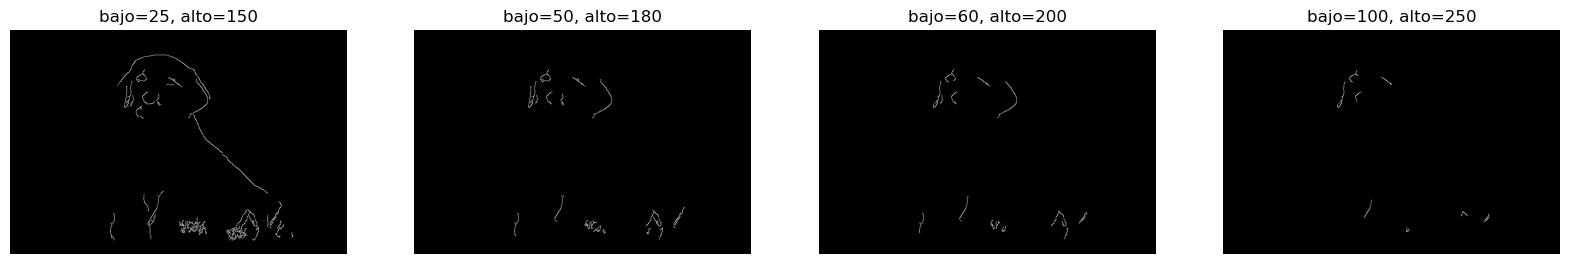

In [12]:
# comparacion de umbrales sobre el perro
comparar_umbrales('complicada1.jpg', [(25, 150), (50, 180), (60, 200), (100, 250)], blur=9, guardar_en='output/complicada1/umbrales.png')

In [13]:
# bloque para guardar los outputs de complicada1
import os
os.makedirs('output/complicada1', exist_ok=True)
cv2.imwrite('output/complicada1/canny.png', canny3)
cv2.imwrite('output/complicada1/bordes_dilatados.png', bordes3)
cv2.imwrite('output/complicada1/segmentada.png', seg3)

True

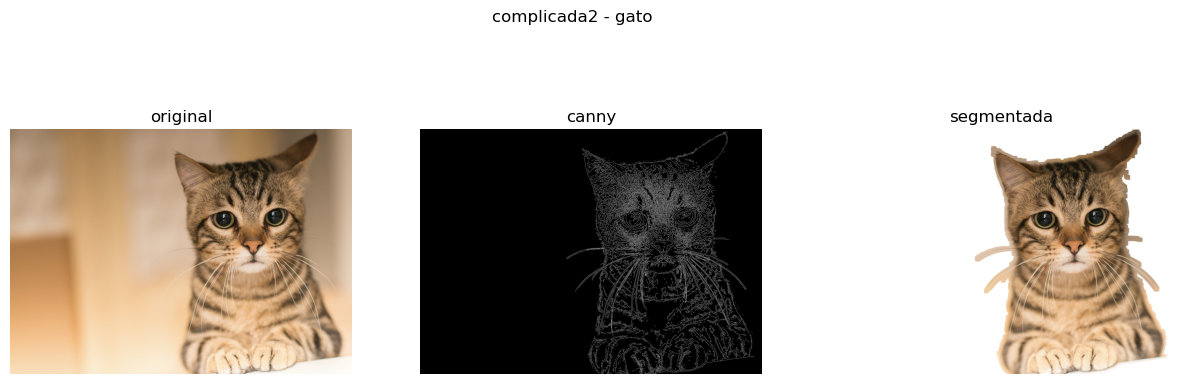

In [14]:
# imagen complicada 2: gato
# umbrales validos (bajo < alto) y kernel grande para cerrar huecos del pelaje
img4, canny4, bordes4, seg4 = segmentar('complicada2.png', 10, 20, k=25, blur=9)
mostrar(img4, canny4, seg4, 'complicada2 - gato', guardar_en='output/complicada2/comparativa.png')

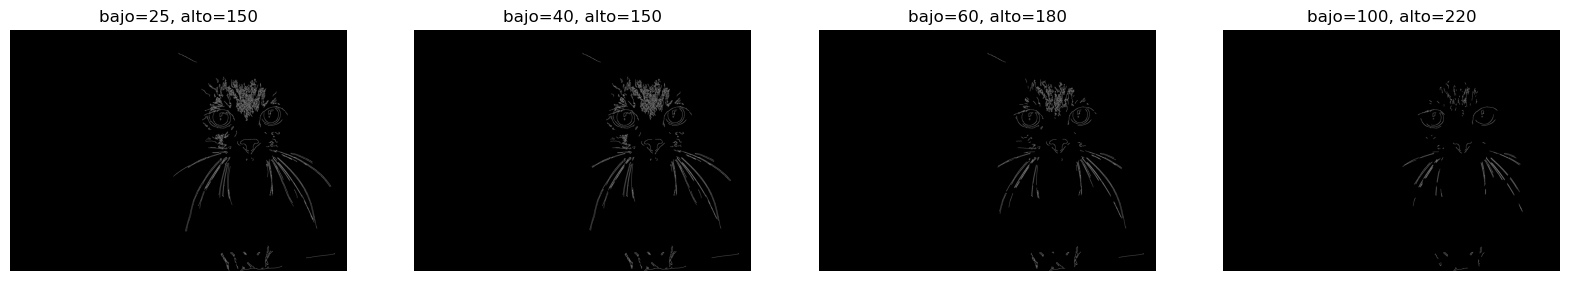

In [15]:
# comparacion de umbrales sobre el gato
comparar_umbrales('complicada2.png', [(25, 150), (40, 150), (60, 180), (100, 220)], blur=9, guardar_en='output/complicada2/umbrales.png')

In [16]:
# bloque para guardar los outputs de complicada2
import os
os.makedirs('output/complicada2', exist_ok=True)
cv2.imwrite('output/complicada2/canny.png', canny4)
cv2.imwrite('output/complicada2/bordes_dilatados.png', bordes4)
cv2.imwrite('output/complicada2/segmentada.png', seg4)

True

In [17]:
# notas para la documentacion:
#
# que cambiamos respecto a la version 1:
# 1) desenfoque bilateral antes de canny -> suaviza pasto, pelaje y fondos texturizados
#    sin perder los bordes nitidos del sujeto. parametro 'blur' controla intensidad.
# 2) cierre morfologico (MORPH_CLOSE) antes de dilatar -> tapa huecos del contorno,
#    util sobre todo en el gato donde los bordes salian fragmentados.
# 3) seleccion ponderada del contorno -> ya no usamos solo el de mayor area, ahora
#    elegimos el que combina area grande + cercania al centro de la imagen.
#    esto evita que el pasto (que estaba todo conectado) gane sobre el sujeto.
#
# papel de los umbrales:
# - umbral alto: bordes seguros (gradiente fuerte)
# - umbral bajo: bordes candidatos que solo sobreviven si se conectan a uno seguro
# - regla: alto debe ser entre 2x y 3x el bajo, si son iguales se rompe la histeresis
# - en imagenes con textura conviene subir el bajo para descartar ruido
# - el blur previo permite usar umbrales mas bajos porque ya removio ruido
#
# aplicaciones de la segmentacion:
# - retoque fotografico (cambio de fondo, efecto retrato)
# - control de calidad industrial (detectar piezas defectuosas en linea)
# - imagen medica (segmentar tumores, organos, lesiones)
# - vision en vehiculos autonomos (peatones, señales, carriles)
# - agricultura de precision (conteo de frutos, deteccion de plagas)
# - vision en robots (separar objeto del entorno antes de manipularlo)